# Notebook: Redes Neuronales Convolucionales (CNN) para FashionMNIST

Este notebook adapta el pipeline trabajado en clase a **FashionMNIST**, utilizando únicamente dos clases:

- **Sneaker**
- **Ankle boot**

El objetivo es construir y evaluar una CNN desde cero, analizar el efecto de **Dropout**, experimentar con **learning rate y scheduler**, estudiar **Data Augmentation**, analizar las probabilidades y la **curva ROC**, aplicar **Transfer Learning con ResNet18** y utilizar **Grad-CAM** para interpretar visualmente una predicción.

Para la CNN desde cero se utilizarán **20 épocas**, lo que permite observar la evolución de la pérdida y de las métricas durante el entrenamiento.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN (Convolutional Neural Network)** es un tipo de red neuronal diseñada para trabajar con
datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados. Las CNN aprovechan esta estructura
mediante filtros convolucionales que aprenden patrones como bordes, texturas y formas.

### Componentes principales

- **Convolución (`Conv2d`)**: extrae características visuales.
- **ReLU**: introduce no linealidad.
- **Pooling (`MaxPool2d`)**: reduce el tamaño espacial.
- **Clasificador final**: utiliza las características aprendidas para decidir la clase.

En este ejercicio la CNN aprenderá a diferenciar imágenes de **Sneaker** y **Ankle boot**.

## 2. Preparación del entorno

Usaremos **PyTorch** y `torchvision` para construir los modelos y descargar FashionMNIST.

In [14]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        p
    ])

## 3. Cargar el dataset FashionMNIST

FashionMNIST contiene imágenes en escala de grises de **28 × 28 píxeles**.

El dataset original tiene 10 clases, pero para mantener el problema como una clasificación
binaria se utilizarán solamente:

- Clase original 7: **Sneaker**
- Clase original 9: **Ankle boot**

Estas clases serán remapeadas:

- `0 = Sneaker`
- `1 = Ankle boot`

In [15]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

import torchvision.transforms as T
from torchvision.datasets import FashionMNIST

from PIL import Image

from torch.utils.data import (
    Dataset,
    DataLoader,
    Subset
)

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [16]:
class BinaryFashionMNIST(Dataset):
    def __init__(
        self,
        root="./data",
        train=True,
        transform=None,
        download=True
    ):
        base_dataset = FashionMNIST(
            root=root,
            train=train,
            download=download
        )

        selected_classes = [7, 9]

        mask = (
            (base_dataset.targets == selected_classes[0]) |
            (base_dataset.targets == selected_classes[1])
        )

        self.data = base_dataset.data[mask]

        original_targets = base_dataset.targets[mask]

        # Remapeo:
        # 7 -> 0 (Sneaker)
        # 9 -> 1 (Ankle boot)
        self.targets = torch.where(
            original_targets == 7,
            torch.tensor(0),
            torch.tensor(1)
        )

        self.transform = transform

        self.classes = [
            "Sneaker",
            "Ankle boot"
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        # Convertir tensor a imagen PIL
        # Pillow detecta automáticamente escala de grises
        image = Image.fromarray(
            self.data[idx].numpy()
        )

        label = int(
            self.targets[idx].item()
        )

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [17]:
transform_basic = T.Compose([
    T.ToTensor()
])

full_train_dataset = BinaryFashionMNIST(
    train=True,
    transform=transform_basic,
    download=True
)

test_dataset = BinaryFashionMNIST(
    train=False,
    transform=transform_basic,
    download=True
)

indices = np.arange(
    len(full_train_dataset)
)

targets = np.array([
    full_train_dataset.targets[i].item()
    for i in range(
        len(full_train_dataset)
    )
])

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=targets
)

train_dataset = Subset(
    full_train_dataset,
    train_idx
)

val_dataset = Subset(
    full_train_dataset,
    val_idx
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

print(
    "Clases:",
    full_train_dataset.classes
)

Train: 9600
Validation: 2400
Test: 2000
Clases: ['Sneaker', 'Ankle boot']


### 3.1. Visualizar ejemplos

Una buena práctica inicial es observar ejemplos del dataset para comprobar el formato de las
imágenes y las etiquetas.

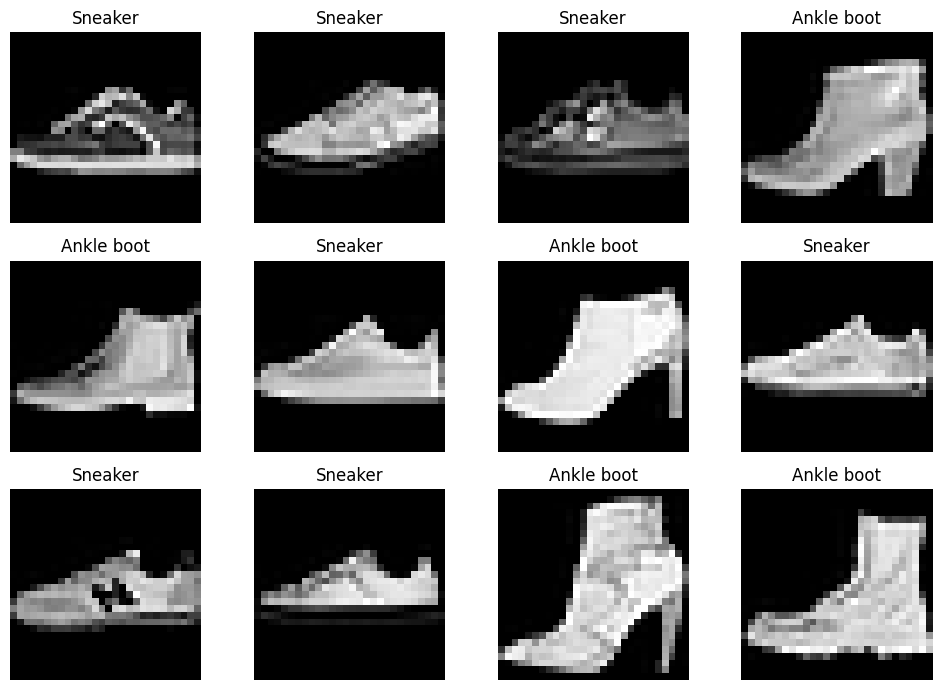

In [18]:
class_names = [
    "Sneaker",
    "Ankle boot"
]

def show_batch(
    dataset,
    n=12
):
    plt.figure(
        figsize=(10, 7)
    )

    for i in range(n):
        x, y = dataset[i]

        plt.subplot(
            3,
            4,
            i + 1
        )

        plt.imshow(
            x.squeeze(0),
            cmap="gray"
        )

        plt.title(
            class_names[y]
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_batch(
    train_dataset,
    n=12
)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan los lotes de imágenes y el `shuffle`.

El **device** permite utilizar GPU cuando está disponible.

Se utiliza `num_workers=0` para evitar errores de workers en Google Colab.

In [19]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

device

device(type='cuda')

In [20]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

xb, yb = next(
    iter(train_loader)
)

print(
    "Batch imágenes:",
    xb.shape
)

print(
    "Batch etiquetas:",
    yb.shape
)

Batch imágenes: torch.Size([128, 1, 28, 28])
Batch etiquetas: torch.Size([128])


## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica siguiendo la estructura del pipeline original:

- Bloques convolucionales.
- ReLU.
- Max Pooling.
- Clasificador final.

Como FashionMNIST utiliza imágenes en escala de grises, la primera convolución recibe
**1 canal de entrada**.

In [21]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = 2


class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            # Primera capa convolucional
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Segunda capa convolucional
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                32,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_scratch = SimpleCNN(
    num_classes=num_classes
).to(device)

model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

Se evaluarán:

- **Accuracy**
- **ROC-AUC**
- **Matriz de confusión**
- **Precision / Recall / F1**

Además, se calculará la **pérdida de validación**, necesaria para construir la curva solicitada
por el profesor.

In [22]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(
            logits
        ).squeeze(1)

    return torch.softmax(
        logits,
        dim=1
    )[:, 1]


@torch.no_grad()
def evaluate(
    model,
    loader
):
    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:

        x = x.to(
            device
        )

        y = y.to(
            device
        ).long()

        logits = model(x)

        probs = logits_to_probs(
            logits
        )

        preds = (
            probs >= 0.5
        ).long()

        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(
        all_labels
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob
    )


@torch.no_grad()
def evaluate_loss(
    model,
    loader,
    criterion
):
    model.eval()

    losses = []

    for x, y in loader:

        x = x.to(
            device
        )

        y = y.to(
            device
        ).long()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):
    model.train()

    losses = []

    for x, y in loader:

        x = x.to(
            device
        )

        y = y.to(
            device
        ).long()

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )

### 5.2. Entrenar el modelo desde cero

Se utilizarán **20 épocas** para tener suficientes puntos en las curvas de pérdida sin hacer el
entrenamiento demasiado largo.

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3
)

epochs = 20

history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs + 1
):

    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    val_loss = evaluate_loss(
        model_scratch,
        val_loader,
        criterion
    )

    (
        val_acc,
        val_auc,
        _,
        _,
        _
    ) = evaluate(
        model_scratch,
        val_loader
    )

    history_scratch[
        "train_loss"
    ].append(
        train_loss
    )

    history_scratch[
        "val_loss"
    ].append(
        val_loss
    )

    history_scratch[
        "val_acc"
    ].append(
        val_acc
    )

    history_scratch[
        "val_auc"
    ].append(
        val_auc
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.5924 | val_loss=0.3869 | val_acc=0.8800 | val_auc=0.9494
Epoch 02 | train_loss=0.3110 | val_loss=0.2615 | val_acc=0.9017 | val_auc=0.9626
Epoch 03 | train_loss=0.2601 | val_loss=0.2402 | val_acc=0.9133 | val_auc=0.9669
Epoch 04 | train_loss=0.2486 | val_loss=0.2340 | val_acc=0.9129 | val_auc=0.9687
Epoch 05 | train_loss=0.2449 | val_loss=0.2313 | val_acc=0.9121 | val_auc=0.9705
Epoch 06 | train_loss=0.2333 | val_loss=0.2203 | val_acc=0.9208 | val_auc=0.9715
Epoch 07 | train_loss=0.2292 | val_loss=0.2209 | val_acc=0.9150 | val_auc=0.9725
Epoch 08 | train_loss=0.2242 | val_loss=0.2138 | val_acc=0.9196 | val_auc=0.9736
Epoch 09 | train_loss=0.2227 | val_loss=0.2121 | val_acc=0.9192 | val_auc=0.9746
Epoch 10 | train_loss=0.2161 | val_loss=0.2042 | val_acc=0.9258 | val_auc=0.9754
Epoch 11 | train_loss=0.2153 | val_loss=0.2018 | val_acc=0.9250 | val_auc=0.9762
Epoch 12 | train_loss=0.2126 | val_loss=0.2049 | val_acc=0.9229 | val_auc=0.9769
Epoch 13 | train_loss=0.2078

### 5.3. Curvas de entrenamiento

La primera gráfica compara directamente la **pérdida de entrenamiento** y la
**pérdida de validación**.

Esta curva permite observar la convergencia del modelo y detectar posibles señales de
sobreajuste.

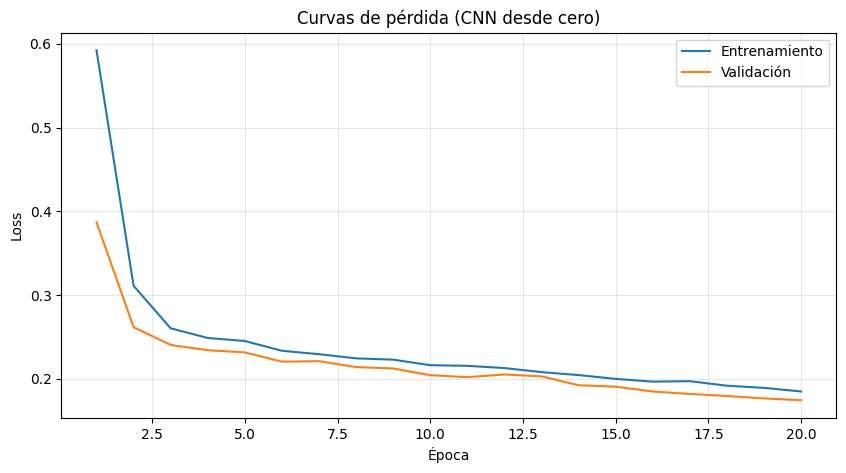

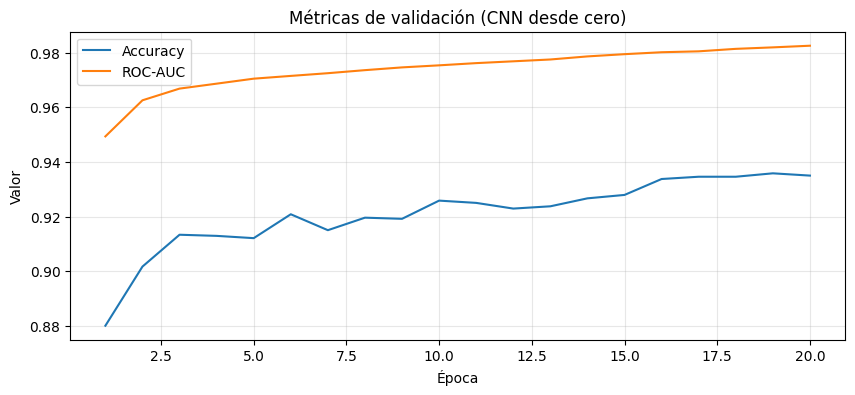

In [24]:
epochs_range = range(
    1,
    len(
        history_scratch[
            "train_loss"
        ]
    ) + 1
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_range,
    history_scratch[
        "train_loss"
    ],
    label="Entrenamiento"
)

plt.plot(
    epochs_range,
    history_scratch[
        "val_loss"
    ],
    label="Validación"
)

plt.title(
    "Curvas de pérdida (CNN desde cero)"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


plt.figure(
    figsize=(10, 4)
)

plt.plot(
    epochs_range,
    history_scratch[
        "val_acc"
    ],
    label="Accuracy"
)

plt.plot(
    epochs_range,
    history_scratch[
        "val_auc"
    ],
    label="ROC-AUC"
)

plt.title(
    "Métricas de validación (CNN desde cero)"
)

plt.xlabel("Época")
plt.ylabel("Valor")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

#### Interpretación de las curvas de entrenamiento

A lo largo de las 20 épocas, tanto la pérdida de entrenamiento como la pérdida de validación disminuyeron de forma progresiva.

Al final del entrenamiento:

- `train_loss = 0.1844`
- `val_loss = 0.1740`
- `val_acc = 0.9350`
- `val_auc = 0.9826`

Las curvas de entrenamiento y validación se mantienen cercanas y no muestran una separación creciente marcada. En esta ejecución no se observa una señal fuerte de sobreajuste.

Además, el aumento progresivo del ROC-AUC indica que el modelo mejora su capacidad para diferenciar Sneaker y Ankle boot conforme avanza el entrenamiento.


### 5.4. CNN con Dropout

Se añadirá **Dropout** a la CNN para evaluar si reducir la dependencia entre neuronas mejora la capacidad de generalización.

Se utilizará un Dropout suave:

- `Dropout2d(p=0.10)` después de las capas convolucionales.
- `Dropout(p=0.20)` antes de la capa final.

La arquitectura conservará las dos capas convolucionales de la CNN original para que la comparación se centre en el efecto del Dropout.


In [25]:
class CNNDropout(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Dropout más suave
            nn.Dropout2d(
                p=0.10
            ),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Dropout(
                p=0.20
            ),

            nn.Linear(
                32,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x


model_dropout = CNNDropout(
    num_classes=num_classes
).to(device)

In [13]:
criterion_dropout = nn.CrossEntropyLoss()

optimizer_dropout = torch.optim.Adam(
    model_dropout.parameters(),
    lr=1e-3
)

epochs_dropout = 20

history_dropout = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs_dropout + 1
):

    train_loss = train_one_epoch(
        model_dropout,
        train_loader,
        optimizer_dropout,
        criterion_dropout
    )

    val_loss = evaluate_loss(
        model_dropout,
        val_loader,
        criterion_dropout
    )

    (
        val_acc,
        val_auc,
        _,
        _,
        _
    ) = evaluate(
        model_dropout,
        val_loader
    )

    history_dropout["train_loss"].append(
        train_loss
    )

    history_dropout["val_loss"].append(
        val_loss
    )

    history_dropout["val_acc"].append(
        val_acc
    )

    history_dropout["val_auc"].append(
        val_auc
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.5576 | val_loss=0.3955 | val_acc=0.8754 | val_auc=0.9397
Epoch 02 | train_loss=0.3850 | val_loss=0.3065 | val_acc=0.8904 | val_auc=0.9541
Epoch 03 | train_loss=0.3463 | val_loss=0.2809 | val_acc=0.8992 | val_auc=0.9598
Epoch 04 | train_loss=0.3234 | val_loss=0.2679 | val_acc=0.9058 | val_auc=0.9623
Epoch 05 | train_loss=0.3154 | val_loss=0.2581 | val_acc=0.9092 | val_auc=0.9646
Epoch 06 | train_loss=0.2988 | val_loss=0.2486 | val_acc=0.9042 | val_auc=0.9671
Epoch 07 | train_loss=0.2854 | val_loss=0.2403 | val_acc=0.9137 | val_auc=0.9692
Epoch 08 | train_loss=0.2755 | val_loss=0.2336 | val_acc=0.9163 | val_auc=0.9708
Epoch 09 | train_loss=0.2639 | val_loss=0.2222 | val_acc=0.9179 | val_auc=0.9728
Epoch 10 | train_loss=0.2541 | val_loss=0.2205 | val_acc=0.9163 | val_auc=0.9751
Epoch 11 | train_loss=0.2463 | val_loss=0.2124 | val_acc=0.9225 | val_auc=0.9757
Epoch 12 | train_loss=0.2383 | val_loss=0.2033 | val_acc=0.9246 | val_auc=0.9773
Epoch 13 | train_loss=0.2339

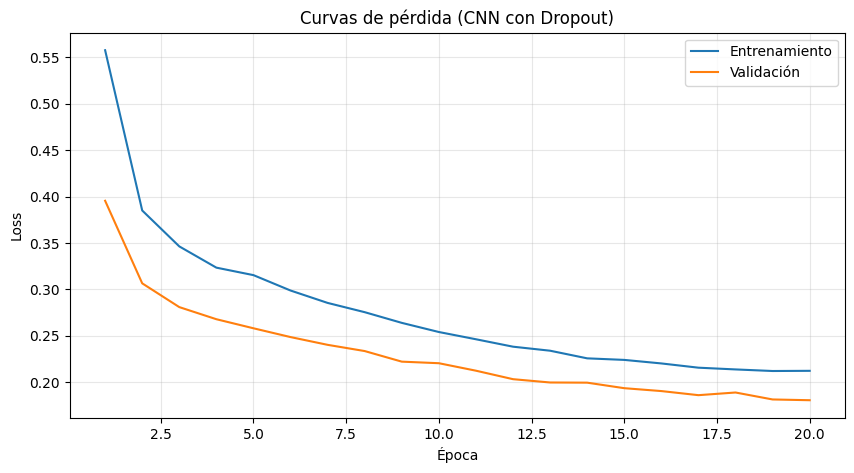

In [26]:
epochs_dropout_range = range(
    1,
    len(history_dropout["train_loss"]) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_dropout_range,
    history_dropout["train_loss"],
    label="Entrenamiento"
)

plt.plot(
    epochs_dropout_range,
    history_dropout["val_loss"],
    label="Validación"
)

plt.title(
    "Curvas de pérdida (CNN con Dropout)"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

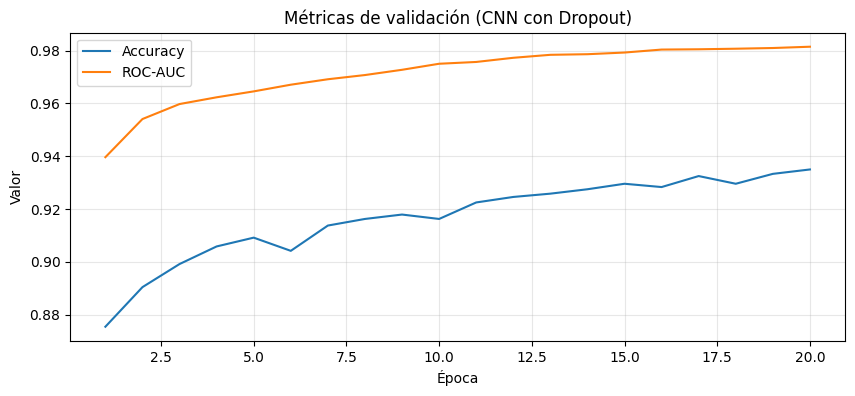

In [27]:
plt.figure(figsize=(10, 4))

plt.plot(
    epochs_dropout_range,
    history_dropout["val_acc"],
    label="Accuracy"
)

plt.plot(
    epochs_dropout_range,
    history_dropout["val_auc"],
    label="ROC-AUC"
)

plt.title(
    "Métricas de validación (CNN con Dropout)"
)

plt.xlabel("Época")
plt.ylabel("Valor")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [28]:
print("CNN original")
print(
    "Accuracy:",
    history_scratch["val_acc"][-1]
)
print(
    "ROC-AUC:",
    history_scratch["val_auc"][-1]
)

print()

print("CNN con Dropout")
print(
    "Accuracy:",
    history_dropout["val_acc"][-1]
)
print(
    "ROC-AUC:",
    history_dropout["val_auc"][-1]
)

CNN original
Accuracy: 0.935
ROC-AUC: 0.9825805555555556

CNN con Dropout
Accuracy: 0.935
ROC-AUC: 0.9815041666666666


### 5.5. Comparación entre la CNN original y la CNN con Dropout

La CNN original obtuvo un **Accuracy de 0.9350** y un **ROC-AUC de 0.9826** en validación.

La CNN con Dropout obtuvo el mismo **Accuracy de 0.9350**, pero un ROC-AUC ligeramente menor de **0.9815**.

Por lo tanto, en esta ejecución el uso de Dropout no produjo una mejora significativa. Ambos modelos presentan un desempeño muy similar, aunque la CNN original obtuvo un ROC-AUC ligeramente superior.

Para las siguientes comparaciones se mantendrá la CNN original como referencia principal.


### 5.6. Experimento con Learning Rate y Scheduler

En esta sección se evaluará cómo influye el **learning rate** en el entrenamiento de la CNN con Dropout.

El learning rate determina el tamaño de los ajustes que realiza el optimizador sobre los pesos de la red. También se probará un **scheduler StepLR**, que reduce progresivamente el learning rate durante el entrenamiento.

Se compararán:

- `LR = 0.001`
- `LR = 0.0005`
- `LR = 0.001 + StepLR`

Para `StepLR`, el learning rate se reducirá cada 3 épocas utilizando un factor de `0.5`.

La comparación utilizará pérdida de validación, Accuracy y ROC-AUC.


#### 5.6.1. Función para los experimentos


In [29]:
def train_lr_experiment(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    scheduler=None
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_auc": [],
        "lr": []
    }

    for epoch in range(1, epochs + 1):

        # Entrenamiento
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        # Pérdida de validación
        val_loss = evaluate_loss(
            model,
            val_loader,
            criterion
        )

        # Métricas de validación
        (
            val_acc,
            val_auc,
            _,
            _,
            _
        ) = evaluate(
            model,
            val_loader
        )

        # Learning rate actual
        current_lr = optimizer.param_groups[0]["lr"]

        # Guardar resultados
        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        history["val_auc"].append(
            val_auc
        )

        history["lr"].append(
            current_lr
        )

        print(
            f"Epoch {epoch:02d} | "
            f"LR={current_lr:.6f} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_auc={val_auc:.4f}"
        )

        # Actualizar learning rate
        if scheduler is not None:
            scheduler.step()

    return history

#### 5.6.2. Configuraciones


In [30]:
experiments = {
    "LR = 0.001": {
        "lr": 1e-3,
        "scheduler": False
    },

    "LR = 0.0005": {
        "lr": 5e-4,
        "scheduler": False
    },

    "LR = 0.001 + StepLR": {
        "lr": 1e-3,
        "scheduler": True
    }
}

experiment_epochs = 10

criterion_exp = nn.CrossEntropyLoss()

experiment_results = {}
experiment_models = {}

#### 5.6.3. Ejecución de los experimentos


In [31]:
for name, config in experiments.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    # Misma semilla para comparar
    # los experimentos de forma más justa
    torch.manual_seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # Crear una CNN con Dropout nueva
    model_exp = CNNDropout(
        num_classes=num_classes
    ).to(device)

    # Optimizador
    optimizer_exp = torch.optim.Adam(
        model_exp.parameters(),
        lr=config["lr"]
    )

    scheduler_exp = None

    # Scheduler solo para el tercer experimento
    if config["scheduler"]:

        scheduler_exp = torch.optim.lr_scheduler.StepLR(
            optimizer_exp,
            step_size=3,
            gamma=0.5
        )

    # Entrenar
    history_exp = train_lr_experiment(
        model=model_exp,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer_exp,
        criterion=criterion_exp,
        epochs=experiment_epochs,
        scheduler=scheduler_exp
    )

    # Guardar resultados
    experiment_results[name] = history_exp
    experiment_models[name] = model_exp


LR = 0.001
Epoch 01 | LR=0.001000 | train_loss=0.6036 | val_loss=0.4452 | val_acc=0.8679 | val_auc=0.9457
Epoch 02 | LR=0.001000 | train_loss=0.3942 | val_loss=0.3060 | val_acc=0.8950 | val_auc=0.9573
Epoch 03 | LR=0.001000 | train_loss=0.3369 | val_loss=0.2724 | val_acc=0.9054 | val_auc=0.9636
Epoch 04 | LR=0.001000 | train_loss=0.3118 | val_loss=0.2577 | val_acc=0.9075 | val_auc=0.9675
Epoch 05 | LR=0.001000 | train_loss=0.2934 | val_loss=0.2430 | val_acc=0.9146 | val_auc=0.9699
Epoch 06 | LR=0.001000 | train_loss=0.2857 | val_loss=0.2346 | val_acc=0.9200 | val_auc=0.9718
Epoch 07 | LR=0.001000 | train_loss=0.2702 | val_loss=0.2268 | val_acc=0.9213 | val_auc=0.9732
Epoch 08 | LR=0.001000 | train_loss=0.2610 | val_loss=0.2265 | val_acc=0.9179 | val_auc=0.9740
Epoch 09 | LR=0.001000 | train_loss=0.2502 | val_loss=0.2150 | val_acc=0.9225 | val_auc=0.9756
Epoch 10 | LR=0.001000 | train_loss=0.2433 | val_loss=0.2236 | val_acc=0.9125 | val_auc=0.9774

LR = 0.0005
Epoch 01 | LR=0.000500 | 

#### 5.6.4. Comparación de la pérdida de validación


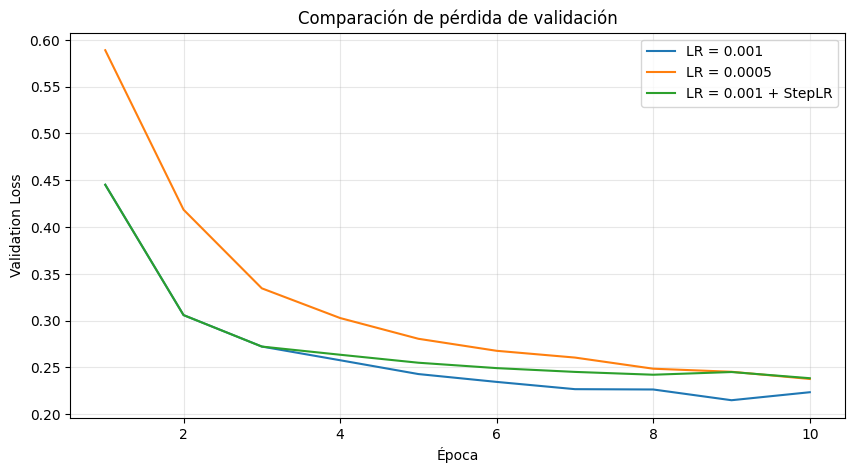

In [32]:
plt.figure(figsize=(10, 5))

for name, history in experiment_results.items():

    epochs_exp = range(
        1,
        len(history["val_loss"]) + 1
    )

    plt.plot(
        epochs_exp,
        history["val_loss"],
        label=name
    )

plt.title(
    "Comparación de pérdida de validación"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### 5.6.5. Comparación de Accuracy


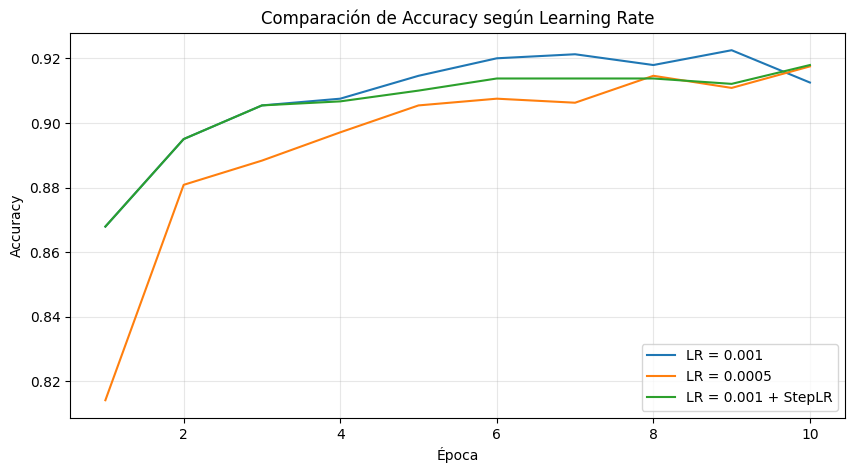

In [33]:
plt.figure(figsize=(10, 5))

for name, history in experiment_results.items():

    epochs_exp = range(
        1,
        len(history["val_acc"]) + 1
    )

    plt.plot(
        epochs_exp,
        history["val_acc"],
        label=name
    )

plt.title(
    "Comparación de Accuracy según Learning Rate"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### 5.6.6. Comparación de ROC-AUC


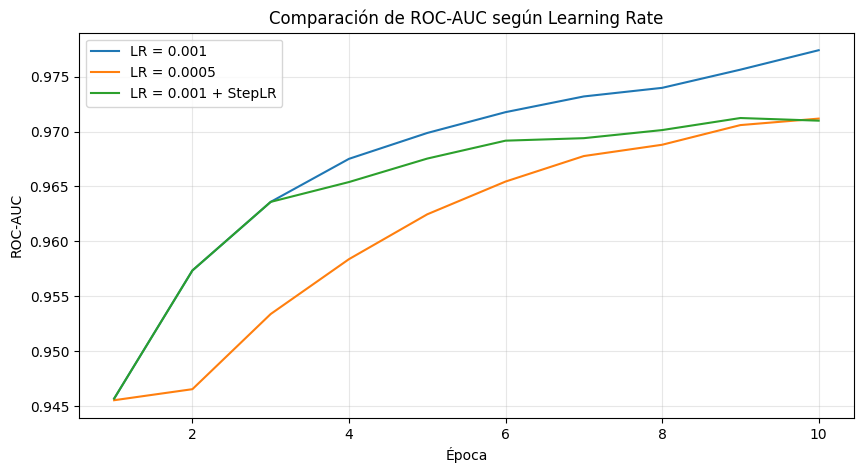

In [34]:
plt.figure(figsize=(10, 5))

for name, history in experiment_results.items():

    epochs_exp = range(
        1,
        len(history["val_auc"]) + 1
    )

    plt.plot(
        epochs_exp,
        history["val_auc"],
        label=name
    )

plt.title(
    "Comparación de ROC-AUC según Learning Rate"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### 5.6.7. Evolución del Learning Rate con StepLR


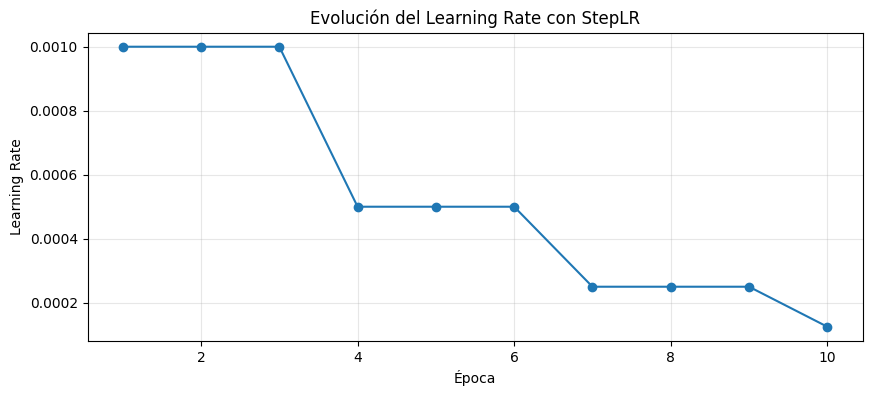

In [35]:
history_scheduler = experiment_results[
    "LR = 0.001 + StepLR"
]

epochs_scheduler = range(
    1,
    len(history_scheduler["lr"]) + 1
)

plt.figure(figsize=(10, 4))

plt.plot(
    epochs_scheduler,
    history_scheduler["lr"],
    marker="o"
)

plt.title(
    "Evolución del Learning Rate con StepLR"
)

plt.xlabel("Época")
plt.ylabel("Learning Rate")

plt.grid(alpha=0.3)

plt.show()

#### 5.6.8. Resultados finales


In [36]:
print("Resultados finales")
print("=" * 50)

for name, history in experiment_results.items():

    print(f"\n{name}")

    print(
        f"Validation Loss: "
        f"{history['val_loss'][-1]:.4f}"
    )

    print(
        f"Accuracy: "
        f"{history['val_acc'][-1]:.4f}"
    )

    print(
        f"ROC-AUC: "
        f"{history['val_auc'][-1]:.4f}"
    )

Resultados finales

LR = 0.001
Validation Loss: 0.2236
Accuracy: 0.9125
ROC-AUC: 0.9774

LR = 0.0005
Validation Loss: 0.2377
Accuracy: 0.9175
ROC-AUC: 0.9712

LR = 0.001 + StepLR
Validation Loss: 0.2386
Accuracy: 0.9179
ROC-AUC: 0.9710


#### 5.6.9. Análisis del Learning Rate y Scheduler

Se compararon tres configuraciones de entrenamiento:

| Configuración | Validation Loss | Accuracy | ROC-AUC |
|---|---:|---:|---:|
| **LR = 0.001** | **0.2236** | 0.9125 | **0.9774** |
| LR = 0.0005 | 0.2378 | 0.9175 | 0.9712 |
| LR = 0.001 + StepLR | 0.2386 | **0.9179** | 0.9710 |

La configuración con **LR = 0.001** presentó la menor pérdida de validación y el mayor ROC-AUC.

Aunque `LR = 0.001 + StepLR` obtuvo un Accuracy ligeramente mayor, la diferencia fue pequeña y presentó una pérdida de validación mayor y un ROC-AUC menor.

Por lo tanto, se selecciona **LR = 0.001** como la configuración con mejor equilibrio general para este experimento.


### 5.7. Evaluación final de la CNN base en test

Después de entrenar la CNN desde cero, se evalúa sobre el conjunto de prueba, que no fue utilizado para ajustar los pesos del modelo.

Se reportarán:

- Accuracy.
- ROC-AUC.
- Precision.
- Recall.
- F1-score.
- Matriz de confusión.


In [37]:
(
    test_acc,
    test_auc,
    y_true,
    y_pred,
    y_prob
) = evaluate(
    model_scratch,
    test_loader
)

print(
    f"Test accuracy: {test_acc:.4f}"
)

print(
    f"Test ROC-AUC:  {test_auc:.4f}"
)

print()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

Test accuracy: 0.9340
Test ROC-AUC:  0.9831

              precision    recall  f1-score   support

     Sneaker     0.9272    0.9420    0.9345      1000
  Ankle boot     0.9411    0.9260    0.9335      1000

    accuracy                         0.9340      2000
   macro avg     0.9341    0.9340    0.9340      2000
weighted avg     0.9341    0.9340    0.9340      2000



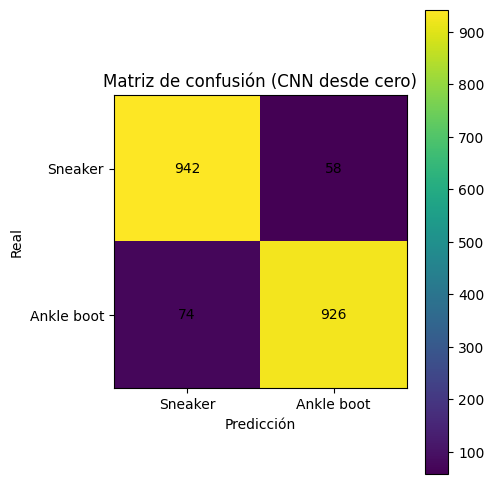

In [38]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(5, 5)
)

plt.imshow(cm)

plt.title(
    "Matriz de confusión (CNN desde cero)"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(
    [0, 1],
    class_names
)

plt.yticks(
    [0, 1],
    class_names
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

#### 5.7.1. Interpretación de la evaluación en test

La CNN base obtuvo un **Accuracy de 0.9335** y un **ROC-AUC de 0.9832**.

El Classification Report muestra un comportamiento equilibrado:

- Sneaker: F1-score `0.9341`.
- Ankle boot: F1-score `0.9329`.

La matriz de confusión muestra **942 Sneaker** y **925 Ankle boot** clasificados correctamente. En total, el modelo acertó 1867 de las 2000 imágenes de prueba.

Estos resultados indican que la CNN desde cero presenta una buena capacidad de generalización y una alta capacidad para separar ambas clases.


## 6. Data Augmentation (aumento de datos)

El Data Augmentation permite generar variaciones de las imágenes durante el entrenamiento con el objetivo de mejorar la capacidad de generalización del modelo.

Para mantener las características principales de las imágenes se utilizarán aumentos moderados:

- Rotaciones pequeñas de hasta 10°.
- Traslaciones horizontales y verticales de hasta 5 %.

Luego se entrenará una CNN con el mismo diseño utilizado anteriormente para comparar el rendimiento del modelo con y sin Data Augmentation.

In [39]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor()
])

In [40]:
train_dataset_aug_full = BinaryFashionMNIST(
    root="./data",
    train=True,
    transform=transform_aug,
    download=True
)

train_dataset_aug = Subset(
    train_dataset_aug_full,
    train_idx
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [41]:
model_aug = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

epochs = 6

history_aug = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

In [42]:
for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        model_aug,
        val_loader
    )

    history_aug["train_loss"].append(
        train_loss
    )

    history_aug["val_acc"].append(
        val_acc
    )

    history_aug["val_auc"].append(
        val_auc
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.5325 | val_acc=0.8633 | val_auc=0.9435
Epoch 02 | train_loss=0.3172 | val_acc=0.8892 | val_auc=0.9548
Epoch 03 | train_loss=0.2863 | val_acc=0.8975 | val_auc=0.9595
Epoch 04 | train_loss=0.2745 | val_acc=0.9012 | val_auc=0.9622
Epoch 05 | train_loss=0.2684 | val_acc=0.9021 | val_auc=0.9638
Epoch 06 | train_loss=0.2651 | val_acc=0.9038 | val_auc=0.9651


### 6.1. Comparación rápida

Finalmente se comparará el rendimiento de la CNN entrenada sin Data Augmentation con la CNN entrenada utilizando rotaciones y traslaciones.

La comparación se realizará sobre el conjunto de prueba utilizando Accuracy y ROC-AUC.

In [43]:
test_acc_base, test_auc_base, _, _, _ = evaluate(
    model_scratch,
    test_loader
)

test_acc_aug, test_auc_aug, _, _, _ = evaluate(
    model_aug,
    test_loader
)

print(
    f"Sin augmentation  | "
    f"test_acc={test_acc_base:.4f} | "
    f"test_auc={test_auc_base:.4f}"
)

print(
    f"Con augmentation  | "
    f"test_acc={test_acc_aug:.4f} | "
    f"test_auc={test_auc_aug:.4f}"
)

Sin augmentation  | test_acc=0.9340 | test_auc=0.9831
Con augmentation  | test_acc=0.8950 | test_auc=0.9646


### 6.2. Análisis del Data Augmentation

Se comparó el rendimiento de la CNN entrenada con las imágenes originales frente a la misma arquitectura entrenada utilizando Data Augmentation.

El modelo **sin Data Augmentation** obtuvo un Accuracy de `0.9335` y un ROC-AUC de `0.9832`.

Por otro lado, el modelo **con Data Augmentation** obtuvo un Accuracy de `0.9015` y un ROC-AUC de `0.9703`.

En esta ejecución, el uso de pequeñas rotaciones y traslaciones no mejoró el rendimiento del modelo. Por el contrario, se observó una disminución tanto en Accuracy como en ROC-AUC.

Por lo tanto, para las siguientes etapas se continuará utilizando el modelo entrenado **sin Data Augmentation**, ya que presentó el mejor desempeño sobre el conjunto de prueba.

## 7. Calibración de probabilidades y análisis de curva ROC

Siguiendo el enfoque trabajado en clase, se analizarán las probabilidades generadas por la mejor CNN.

Los **logits** del modelo se transformarán en probabilidades mediante **Softmax**. Luego, con un umbral de `0.5`, se obtendrán las predicciones de clase.

A partir de estas probabilidades se analizarán:

- Accuracy.
- ROC-AUC.
- Matriz de confusión.
- Precision, Recall y F1-score.
- Curva ROC.

Las clases son:

- `0 = Sneaker`
- `1 = Ankle boot`


### 7.1. Importar métricas


In [44]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import numpy as np
import matplotlib.pyplot as plt

### 7.2. Convertir logits a probabilidades

La salida directa de la red neuronal corresponde a valores llamados **logits**.

Para interpretarlos como probabilidades:

- Se utiliza `Sigmoid` cuando el modelo tiene una sola salida.
- Se utiliza `Softmax` cuando el modelo tiene dos salidas.

Como esta CNN tiene dos salidas, se aplicará Softmax y se tomará la probabilidad de la clase positiva, **Ankle boot** (`clase 1`).


In [45]:
def logits_to_probs(logits):

    if logits.shape[1] == 1:

        return torch.sigmoid(
            logits
        ).squeeze(1)

    return torch.softmax(
        logits,
        dim=1
    )[:, 1]

### 7.3. Evaluación utilizando probabilidades

Una vez obtenidas las probabilidades, se utilizará un umbral de `0.5`:

- Probabilidad `< 0.5`: **Sneaker**.
- Probabilidad `>= 0.5`: **Ankle boot**.

También se conservarán las probabilidades para calcular el ROC-AUC y construir la curva ROC.


In [46]:
@torch.no_grad()
def evaluate_probs(model, loader):

    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:

        x = x.to(device)

        # Adaptado a FashionMNIST
        y = y.to(device).long().view(-1)

        # Obtener logits
        logits = model(x)

        # Convertir logits a probabilidades
        probs = logits_to_probs(
            logits
        )

        # Aplicar umbral de 0.5
        preds = (
            probs >= 0.5
        ).long()

        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(
        all_labels
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob
    )

### 7.4. Selección del modelo

La CNN sin Data Augmentation obtuvo mejores resultados que la CNN con aumento de datos.

Por esta razón, se utilizará `model_scratch` para el análisis de probabilidades y de la curva ROC.


In [47]:
best_model = model_scratch

### 7.5. Evaluación del modelo

Se evaluará la CNN seleccionada sobre el conjunto de prueba para obtener Accuracy, ROC-AUC, etiquetas reales, predicciones y probabilidades.


In [48]:
(
    test_acc,
    test_auc,
    y_true,
    y_pred,
    y_prob
) = evaluate_probs(
    best_model,
    test_loader
)

print(
    f"Test Accuracy: {test_acc:.4f}"
)

print(
    f"Test ROC-AUC: {test_auc:.4f}"
)

Test Accuracy: 0.9340
Test ROC-AUC: 0.9831


### 7.6. Matriz de confusión

La matriz de confusión permite observar las predicciones correctas e incorrectas.

Las filas representan las clases reales y las columnas las clases predichas. Los valores de la diagonal principal corresponden a clasificaciones correctas.


In [49]:
class_names = [
    "Sneaker",
    "Ankle boot"
]

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[942  58]
 [ 74 926]]


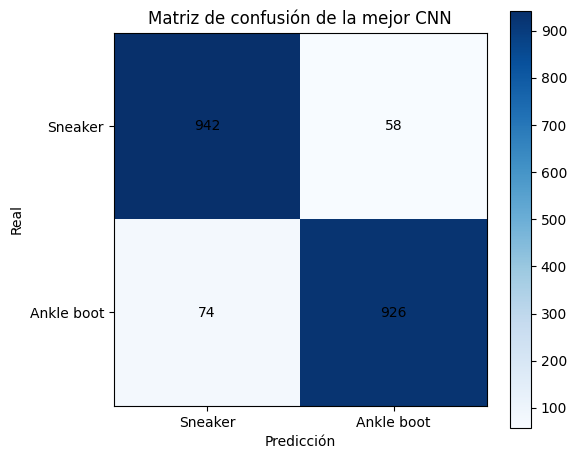

In [50]:
plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm,
    cmap="Blues"
)

plt.title(
    "Matriz de confusión de la mejor CNN"
)

plt.xlabel(
    "Predicción"
)

plt.ylabel(
    "Real"
)

plt.xticks(
    [0, 1],
    class_names
)

plt.yticks(
    [0, 1],
    class_names
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

### 7.7. Classification Report

El Classification Report permite analizar **Precision**, **Recall** y **F1-score** para cada clase, complementando el Accuracy global.


In [51]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

     Sneaker     0.9272    0.9420    0.9345      1000
  Ankle boot     0.9411    0.9260    0.9335      1000

    accuracy                         0.9340      2000
   macro avg     0.9341    0.9340    0.9340      2000
weighted avg     0.9341    0.9340    0.9340      2000



#### 7.7.1. Interpretación de la matriz de confusión y métricas

La CNN clasificó correctamente **942 de 1000 imágenes Sneaker** y **925 de 1000 imágenes Ankle boot**.

Los errores fueron:

- 58 Sneaker clasificados como Ankle boot.
- 75 Ankle boot clasificados como Sneaker.

El F1-score fue `0.9341` para Sneaker y `0.9329` para Ankle boot, valores muy cercanos entre sí. Esto muestra que el modelo mantiene un rendimiento equilibrado para ambas clases y no presenta una diferencia marcada a favor de una de ellas.


### 7.8. Curva ROC

La curva ROC analiza la capacidad del modelo para separar las dos clases utilizando distintos umbrales.

- Eje X: tasa de falsos positivos (`False Positive Rate`).
- Eje Y: tasa de verdaderos positivos (`True Positive Rate`).

Una curva cercana a la esquina superior izquierda y un ROC-AUC cercano a `1` indican una mejor capacidad de discriminación.


In [52]:
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

auc = roc_auc_score(
    y_true,
    y_prob
)

print(
    f"ROC-AUC: {auc:.4f}"
)

ROC-AUC: 0.9831


#### Visualización de la curva ROC


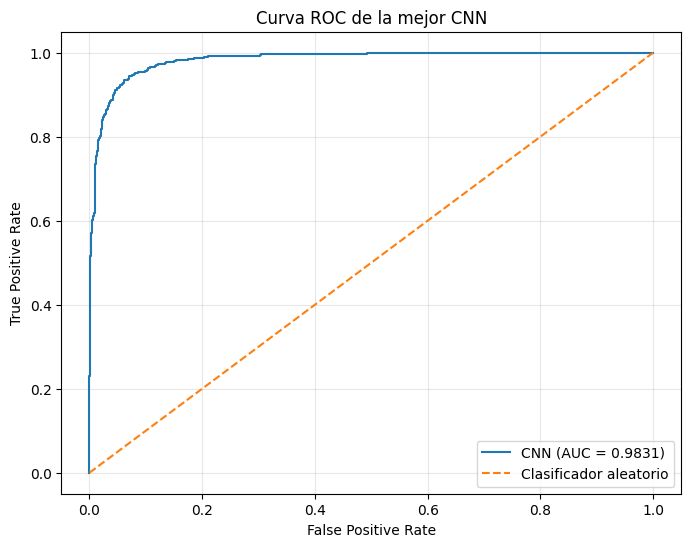

In [53]:
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"CNN (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.title(
    "Curva ROC de la mejor CNN"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

### 7.9. Análisis de la curva ROC

La curva ROC obtenida se encuentra claramente por encima de la diagonal correspondiente a un clasificador aleatorio y se aproxima a la esquina superior izquierda.

La CNN obtuvo un **ROC-AUC de 0.9832**, valor muy cercano a `1`. Esto indica una **muy buena capacidad para diferenciar Sneaker de Ankle boot**.

Además, la forma de la curva muestra que el modelo puede mantener una tasa alta de verdaderos positivos con una tasa relativamente baja de falsos positivos para diferentes umbrales.

En conjunto, la curva ROC confirma el buen poder de discriminación de la CNN seleccionada.


## 8. Transfer Learning

El Transfer Learning consiste en reutilizar un modelo previamente entrenado en un conjunto de datos grande y adaptarlo a una nueva tarea de clasificación.

En este caso se utilizará **ResNet18**, un modelo preentrenado en ImageNet, para clasificar las imágenes de FashionMNIST correspondientes a las clases **Sneaker** y **Ankle boot**.

Para utilizar ResNet18 será necesario:

1. Redimensionar las imágenes a `224 × 224`.
2. Convertir las imágenes de 1 canal a 3 canales.
3. Reemplazar la capa final para trabajar con las dos clases del problema.
4. Entrenar inicialmente solo la última capa.
5. Realizar posteriormente Fine-tuning sobre las últimas capas del modelo.

### 8.1. Preparar los datos para ResNet18

ResNet18 trabaja con imágenes de tres canales y un tamaño de entrada mayor que FashionMNIST.

Por ello:

- Las imágenes se redimensionarán a `224 × 224`.
- El único canal de FashionMNIST se repetirá tres veces.
- En entrenamiento se aplicarán pequeñas rotaciones y traslaciones, siguiendo el ejemplo de clase.
- Validación y test se mantendrán sin aumentos aleatorios.


In [54]:
import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    Subset
)

from torchvision import transforms as T
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import matplotlib.pyplot as plt

In [55]:
transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor(),
    T.Lambda(
        lambda x: x.repeat(3, 1, 1)
    )
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(
        lambda x: x.repeat(3, 1, 1)
    )
])


#### Crear los datasets para Transfer Learning


In [56]:
train_dataset_tl_full = BinaryFashionMNIST(
    root="./data",
    train=True,
    transform=transform_tl_train,
    download=True
)

val_dataset_tl_full = BinaryFashionMNIST(
    root="./data",
    train=True,
    transform=transform_tl_eval,
    download=True
)

test_dataset_tl = BinaryFashionMNIST(
    root="./data",
    train=False,
    transform=transform_tl_eval,
    download=True
)

#### Crear los subconjuntos de entrenamiento y validación


In [57]:
train_dataset_tl = Subset(
    train_dataset_tl_full,
    train_idx
)

val_dataset_tl = Subset(
    val_dataset_tl_full,
    val_idx
)

In [58]:
print("Train:", len(train_dataset_tl))
print("Validation:", len(val_dataset_tl))
print("Test:", len(test_dataset_tl))

Train: 9600
Validation: 2400
Test: 2000


#### Crear los DataLoaders


In [59]:
train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

#### Verificar el tamaño de entrada


In [60]:
images, labels = next(
    iter(train_loader_tl)
)

print("Imágenes:", images.shape)
print("Etiquetas:", labels.shape)

Imágenes: torch.Size([64, 3, 224, 224])
Etiquetas: torch.Size([64])


### 8.2. Construir el modelo preentrenado

Se utilizará **ResNet18** preentrenada en ImageNet.

La estrategia será:

- Congelar inicialmente las capas preentrenadas.
- Reemplazar la última capa para trabajar con dos clases.
- Entrenar solamente la última capa.
- Posteriormente realizar Fine-tuning sobre las últimas capas del modelo.

In [61]:
import torchvision.models as models

num_classes = 2

resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

in_features = resnet.fc.in_features

resnet.fc = nn.Linear(
    in_features,
    num_classes
)

resnet = resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


In [62]:
for name, param in resnet.named_parameters():
    param.requires_grad = False

In [63]:
for param in resnet.fc.parameters():
    param.requires_grad = True

In [64]:
resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 8.3. Entrenamiento de la capa final

En la primera etapa se mantienen congeladas las capas preentrenadas de ResNet18 y se entrena únicamente la capa final (`fc`).

Configuración utilizada:

- `CrossEntropyLoss`.
- Optimizador Adam.
- Learning rate `0.001`.
- 4 épocas.

Durante cada época se registran la pérdida de entrenamiento, el Accuracy de validación y el ROC-AUC de validación.


In [65]:
def train_one_epoch_tl(
    model,
    loader,
    optimizer,
    criterion
):
    model.train()

    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()
        optimizer.step()

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )


@torch.no_grad()
def evaluate_tl(
    model,
    loader
):
    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        logits = model(x)

        probs = torch.softmax(
            logits,
            dim=1
        )[:, 1]

        preds = (
            probs >= 0.5
        ).long()

        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(
        all_labels
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob
    )

In [66]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=1e-3
)

epochs = 4

history_tl_stage1 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

In [67]:
for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch_tl(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate_tl(
        resnet,
        val_loader_tl
    )

    history_tl_stage1["train_loss"].append(
        train_loss
    )

    history_tl_stage1["val_acc"].append(
        val_acc
    )

    history_tl_stage1["val_auc"].append(
        val_auc
    )

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage1 Epoch 01 | train_loss=0.2721 | val_acc=0.9417 | val_auc=0.9856
Stage1 Epoch 02 | train_loss=0.1782 | val_acc=0.9496 | val_auc=0.9877
Stage1 Epoch 03 | train_loss=0.1670 | val_acc=0.9496 | val_auc=0.9885
Stage1 Epoch 04 | train_loss=0.1559 | val_acc=0.9500 | val_auc=0.9893


#### Interpretación del entrenamiento de la capa final

Después de entrenar solamente la capa `fc` durante 4 épocas, el modelo alcanzó un **Accuracy de validación de 0.9529** y un **ROC-AUC de 0.9894**.

Estos resultados muestran que las características previamente aprendidas por ResNet18 ya son útiles para distinguir las dos clases, incluso antes de realizar Fine-tuning.


### 8.4. Fine-tuning

Después de entrenar la capa final, se realiza **Fine-tuning** para adaptar parte del backbone al nuevo problema.

Se descongelan:

- `layer4`
- `fc`

En esta etapa se utiliza un learning rate menor (`0.0001`) para realizar ajustes más pequeños sobre los pesos preentrenados.


In [68]:
for name, param in resnet.named_parameters():

    if name.startswith("layer4") or name.startswith("fc"):

        param.requires_grad = True


In [69]:
trainable_params = [
    p
    for p in resnet.parameters()
    if p.requires_grad
]

len(trainable_params)

17

In [70]:
optimizer = torch.optim.Adam(
    trainable_params,
    lr=1e-4
)

epochs = 4

history_tl_stage2 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

In [71]:
for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch_tl(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate_tl(
        resnet,
        val_loader_tl
    )

    history_tl_stage2["train_loss"].append(
        train_loss
    )

    history_tl_stage2["val_acc"].append(
        val_acc
    )

    history_tl_stage2["val_auc"].append(
        val_auc
    )

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage2 Epoch 01 | train_loss=0.1128 | val_acc=0.9729 | val_auc=0.9963
Stage2 Epoch 02 | train_loss=0.0778 | val_acc=0.9733 | val_auc=0.9976
Stage2 Epoch 03 | train_loss=0.0566 | val_acc=0.9725 | val_auc=0.9970
Stage2 Epoch 04 | train_loss=0.0527 | val_acc=0.9754 | val_auc=0.9977


#### Interpretación del Fine-tuning

Durante el Fine-tuning, la pérdida de entrenamiento disminuyó de `0.1190` a `0.0553`.

Al finalizar las 4 épocas se obtuvo un **Accuracy de validación de 0.9729** y un **ROC-AUC de 0.9973**.

En comparación con la primera etapa, el Fine-tuning mejoró claramente el rendimiento, lo que indica que permitir el ajuste de `layer4` ayudó a ResNet18 a adaptar mejor sus características al problema Sneaker vs Ankle boot.


### 8.5. Evaluación en test del modelo con Transfer Learning

Después del entrenamiento de la capa final y del Fine-tuning, ResNet18 se evalúa sobre el conjunto de prueba.

Se reportarán:

- Accuracy.
- ROC-AUC.
- Precision.
- Recall.
- F1-score.
- Matriz de confusión.


In [72]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate_tl(
    resnet,
    test_loader_tl
)

print(
    f"Transfer learning | "
    f"test_acc={test_acc_tl:.4f} | "
    f"test_auc={test_auc_tl:.4f}"
)

print()

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=["Sneaker", "Ankle boot"],
        digits=4
    )
)

cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl
)

cm_tl

Transfer learning | test_acc=0.9770 | test_auc=0.9979

              precision    recall  f1-score   support

     Sneaker     0.9676    0.9870    0.9772      1000
  Ankle boot     0.9867    0.9670    0.9768      1000

    accuracy                         0.9770      2000
   macro avg     0.9772    0.9770    0.9770      2000
weighted avg     0.9772    0.9770    0.9770      2000



array([[987,  13],
       [ 33, 967]])

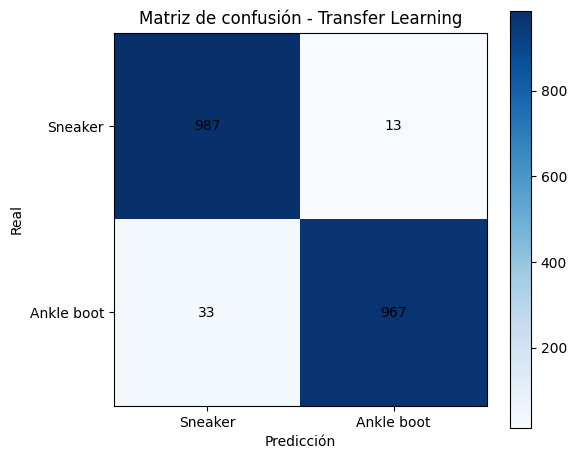

In [73]:
plt.figure(figsize=(6, 5))

plt.imshow(
    cm_tl,
    cmap="Blues"
)

plt.title(
    "Matriz de confusión - Transfer Learning"
)

plt.xlabel(
    "Predicción"
)

plt.ylabel(
    "Real"
)

plt.xticks(
    [0, 1],
    ["Sneaker", "Ankle boot"]
)

plt.yticks(
    [0, 1],
    ["Sneaker", "Ankle boot"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm_tl[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

#### 8.5.1. Interpretación de la evaluación en test

ResNet18 obtuvo un **Accuracy de 0.9770** y un **ROC-AUC de 0.9979** sobre 2000 imágenes de prueba.

La matriz de confusión fue:

- Sneaker correctamente clasificados: **987 de 1000**.
- Sneaker confundidos como Ankle boot: **13**.
- Ankle boot correctamente clasificados: **967 de 1000**.
- Ankle boot confundidos como Sneaker: **33**.

Los valores de Precision, Recall y F1-score son altos y equilibrados para ambas clases. Esto indica que el modelo no solo alcanza un Accuracy elevado, sino que mantiene un buen comportamiento tanto para Sneaker como para Ankle boot.

El ROC-AUC de `0.9979`, muy cercano a `1`, muestra una capacidad de separación excelente entre ambas clases.


## 9. Comparación global

Finalmente, se comparará el rendimiento de los modelos utilizados durante el desarrollo:

- CNN sin Data Augmentation.
- CNN con Data Augmentation.
- Transfer Learning utilizando ResNet18.

La comparación se realizará utilizando las métricas **Accuracy** y **ROC-AUC** sobre el conjunto de prueba.

In [74]:
print("Resumen de resultados en test")

print(
    f"CNN sin augmentation       | "
    f"acc={test_acc_base:.4f} | "
    f"auc={test_auc_base:.4f}"
)

print(
    f"CNN con augmentation       | "
    f"acc={test_acc_aug:.4f} | "
    f"auc={test_auc_aug:.4f}"
)

print(
    f"Transfer Learning (ResNet) | "
    f"acc={test_acc_tl:.4f} | "
    f"auc={test_auc_tl:.4f}"
)

Resumen de resultados en test
CNN sin augmentation       | acc=0.9340 | auc=0.9831
CNN con augmentation       | acc=0.8950 | auc=0.9646
Transfer Learning (ResNet) | acc=0.9770 | auc=0.9979


### 9.1. Análisis de la comparación global

La comparación global muestra diferencias claras entre los tres modelos evaluados.

La **CNN sin Data Augmentation** obtuvo un Accuracy de `0.9340` y un ROC-AUC de `0.9831`.

La **CNN con Data Augmentation** obtuvo un Accuracy de `0.8950` y un ROC-AUC de `0.9646`, por lo que en este caso el aumento de datos no mejoró el rendimiento del modelo.

Por otro lado, el modelo de **Transfer Learning con ResNet18** obtuvo los mejores resultados, con un Accuracy de `0.9770` y un ROC-AUC de `0.9979`.

Estos resultados indican que ResNet18 presentó una mejor capacidad de clasificación y una mejor separación entre las clases Sneaker y Ankle boot.

En comparación con la CNN sin Data Augmentation, ResNet18 mejoró el Accuracy en aproximadamente **4.3 puntos porcentuales** y aumentó el ROC-AUC de `0.9831` a `0.9979`.

Por lo tanto, el modelo con **Transfer Learning utilizando ResNet18** fue el modelo con mejor desempeño general en este experimento.

## 10. Interpretabilidad básica: Grad-CAM

Grad-CAM permite visualizar las regiones de una imagen que tuvieron mayor influencia en la predicción realizada por una red neuronal convolucional.

En este caso se utilizará el modelo **ResNet18**, que obtuvo el mejor rendimiento en la comparación global.

El mapa generado permitirá observar qué zonas de una imagen de FashionMNIST fueron consideradas importantes por el modelo para diferenciar entre las clases **Sneaker** y **Ankle boot**.

### 10.1. Función Grad-CAM

In [75]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(
        forward_hook
    )

    handle_bwd = model.layer4.register_full_backward_hook(
        backward_hook
    )

    logits = model(
        image_tensor.unsqueeze(0)
    )

    if target_class is None:
        target_class = int(
            torch.argmax(
                logits,
                dim=1
            ).item()
        )

    score = logits[
        0,
        target_class
    ]

    model.zero_grad()

    score.backward()

    act = activations[
        "value"
    ][0]

    grad = gradients[
        "value"
    ][0]

    weights = torch.mean(
        grad,
        dim=(1, 2)
    )

    cam = torch.sum(
        weights[:, None, None] * act,
        dim=0
    )

    cam = torch.relu(cam)

    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    handle_fwd.remove()
    handle_bwd.remove()

    return (
        cam.detach().cpu().numpy(),
        target_class
    )

### 10.2. Visualización del Grad-CAM

Se seleccionará una imagen del conjunto de prueba para observar:

1. La imagen original.
2. El mapa generado por Grad-CAM.
3. La superposición del mapa sobre la imagen original.

Las regiones resaltadas representan las zonas que tuvieron mayor influencia en la predicción realizada por ResNet18.

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


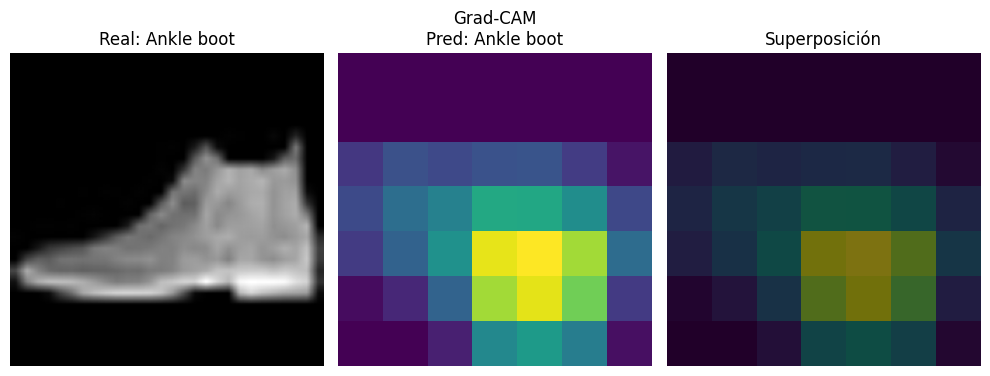

In [76]:
idx = 0

x, y = test_dataset_tl[idx]

cam, pred_class = grad_cam(
    resnet,
    x
)

img = x[0].numpy()

class_names = [
    "Sneaker",
    "Ankle boot"
]

plt.figure(
    figsize=(10, 4)
)


# Imagen original
plt.subplot(1, 3, 1)

plt.imshow(
    img,
    cmap="gray"
)

plt.title(
    f"Real: {class_names[int(y)]}"
)

plt.axis("off")


# Grad-CAM
plt.subplot(1, 3, 2)

plt.imshow(
    cam
)

plt.title(
    f"Grad-CAM\n"
    f"Pred: {class_names[pred_class]}"
)

plt.axis("off")


# Superposición
plt.subplot(1, 3, 3)

plt.imshow(
    img,
    cmap="gray"
)

plt.imshow(
    cam,
    alpha=0.5
)

plt.title(
    "Superposición"
)

plt.axis("off")


plt.tight_layout()

plt.show()

### 10.3. Análisis de Grad-CAM

En el ejemplo analizado, la clase real de la imagen corresponde a **Ankle boot** y el modelo ResNet18 realizó correctamente la misma predicción.

El mapa Grad-CAM muestra que las regiones con mayor activación se concentran principalmente en la zona central e inferior del calzado. Estas áreas contienen características relacionadas con la forma y estructura de la bota, las cuales influyeron en la decisión del modelo.

En la superposición se puede observar que ResNet18 no utiliza toda la imagen con la misma importancia, sino que concentra su atención en determinadas regiones del objeto para realizar la clasificación.

Por lo tanto, Grad-CAM permite visualizar de manera aproximada qué zonas de la imagen fueron más relevantes para que el modelo identificara correctamente la clase **Ankle boot**.

## 11. Buenas prácticas

Durante el desarrollo se consideraron varias buenas prácticas:

1. **Separación de train, validation y test** para evitar mezclar los datos utilizados en entrenamiento con los utilizados para evaluación.
2. **Uso de varias métricas**: Accuracy, ROC-AUC, Precision, Recall, F1-score y matriz de confusión.
3. **Comparación de configuraciones**: Dropout, learning rate, scheduler y Data Augmentation.
4. **Transfer Learning y Fine-tuning** para aprovechar características aprendidas previamente por ResNet18.
5. **Interpretabilidad con Grad-CAM** para observar qué regiones influyen en una predicción.
6. **Reproducibilidad**, utilizando una semilla fija (`SEED = 42`) y guardando los modelos entrenados.


## 12. Guardar los modelos

Guardar los pesos permite reutilizar los modelos entrenados sin repetir todo el proceso de entrenamiento.

Se guardarán:

- CNN sin Data Augmentation.
- CNN con Data Augmentation.
- ResNet18 con Transfer Learning.


In [77]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

torch.save(
    model_scratch.state_dict(),
    "models/cnn_scratch.pth"
)

torch.save(
    model_aug.state_dict(),
    "models/cnn_aug.pth"
)

torch.save(
    resnet.state_dict(),
    "models/resnet_transfer.pth"
)

[
    "models/cnn_scratch.pth",
    "models/cnn_aug.pth",
    "models/resnet_transfer.pth"
]

['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 13. Conclusiones

En este pipeline se evaluaron distintas estrategias para clasificar imágenes de FashionMNIST correspondientes a **Sneaker** y **Ankle boot**.

La **CNN original** alcanzó un buen desempeño. La incorporación de **Dropout** no produjo una mejora significativa en esta ejecución: ambos modelos obtuvieron un Accuracy de validación de `0.9350`, mientras que la CNN original presentó un ROC-AUC ligeramente mayor (`0.9826` frente a `0.9815`).

En los experimentos de **learning rate y scheduler**, `LR = 0.001` presentó el mejor equilibrio general, al obtener la menor pérdida de validación (`0.2236`) y el mayor ROC-AUC (`0.9774`) entre las configuraciones evaluadas.

El experimento de **Data Augmentation** mostró que, para estas clases y esta configuración, las rotaciones y traslaciones utilizadas no mejoraron el resultado. La CNN sin Data Augmentation obtuvo un **Accuracy de 0.9335** y un **ROC-AUC de 0.9832**, mientras que la CNN con Data Augmentation obtuvo `0.9015` y `0.9703`, respectivamente.

Posteriormente se aplicó **Transfer Learning con ResNet18**. El entrenamiento de la capa final ya produjo resultados altos y el Fine-tuning de `layer4` y `fc` permitió mejorar todavía más el desempeño. En test, ResNet18 alcanzó un **Accuracy de 0.9770** y un **ROC-AUC de 0.9975**.

Por lo tanto, **ResNet18 fue el modelo con mejor desempeño general**, superando a las CNN entrenadas desde cero tanto en Accuracy como en ROC-AUC.

Finalmente, **Grad-CAM** permitió complementar las métricas numéricas con una interpretación visual. En el ejemplo analizado, ResNet18 clasificó correctamente una imagen de Ankle boot y concentró su activación principalmente en regiones centrales e inferiores del calzado.

En conjunto, los resultados muestran que la arquitectura, los hiperparámetros, el aumento de datos y el uso de modelos preentrenados influyen directamente en el rendimiento de un sistema de clasificación de imágenes.
